# Bepaling van warmtecapaciteit van een onbekend materiaal


# Introductie

Onbekende materialen kunnen geïdentificeerd worden door hun eigenschappen te meten. Een van deze eigenschappen is de warmtecapaciteit. In dit practicum gaan we de warmtecapaciteit van een onbekend materiaal bepalen door middel van een calorimeter experiment. Daarbij wordt een bepaalde massa van het materiaal naar een bekende temperatuur gebracht waarna het in een bekende hoeveelheid water met bekende temperatuur wordt geplaatst. Door de temperatuur van het water te meten na het mengen kan de warmtecapaciteit van het onbekende materiaal worden berekend.

# Theorie

De soortelijke warmte $c$ van een materiaal is gedefinieerd als de hoeveelheid warmte $Q$ die nodig is om de temperatuur $T$ van een kilogram van het materiaal met één graad Celsius (of één Kelvin) te verhogen:

$$
    c = \frac{Q}{m \Delta T}
$$ (eq:heat_capacity)

Waarbij $Q$ de hoeveelheid warmte in Joules is, $m$ de massa in kilogram is en $\Delta T$ de verandering in temperatuur is. Gegeven de wet van Black, die stelt dat de totale hoeveelheid warmte in een geïsoleerd systeem constant blijft, kunnen we de warmte die het onbekende materiaal verliest gelijkstellen aan de warmte die het water opneemt:

$$
    Q_{materiaal} = -Q_{water} 
$$ (eq:black)

wanneer we de massa's en de begintemperaturen van beide systemen kennen, maar slechts een van de twee soortelijke warmtes, kunnen we de onbekende soortelijke warmte berekenen. We combineren vergelijkingen [](#eq:heat_capacity) en [](#eq:black) om de volgende vergelijking te krijgen:

$$
    T_e = \frac{c_w m_w T_{w,b}+c_m m_m T_{m,b}}{c_w m_w + c_m m_m}
$$ (eq:combined)

Waarbij de subscripts $b$ en $e$ respectievelijk staan voor begintoestand en eindtoestand, $w$ voor water en $m$ voor het onbekende materiaal.

Bij metingen aan verschillende massa's van het onbekende materiaal en vervolgens een least square fit aan bovenstaande vergelijking kunnen we een precieze waarde voor de soortelijke warmte van het onbekende materiaal bepalen. Dat is, wanneer de warmtecapaciteit van bijvoorbeeld de beker te verwaarlozen is.


# Methode en materialen

## Ontwerp
De bovenstaande theorie wordt gebruikt om de soortelijke warmte van een onbekend materiaal te bepalen. Het experiment bestaat uit het verwarmen van verschillende massa's van het onbekende materiaal tot een bekende temperatuur, waarna het in een bekende hoeveelheid water met bekende temperatuur wordt geplaats. Door de temperatuur van het water te meten na het mengen kan de warmtecapaciteit van het onbekende materiaal worden berekend. Om de tijd voor het meten van meerdere materialen te reduceren, worden de data van de verschillende groepen in het lokaal samengevoegd. Van tevoren is afgesproken welke massa's door welke groep worden gemeten, en hoeveel water er gebruikt wordt.

## Materialen
Hieronder staat de lijst van benodigde materialen bij deze proef:
- Calorimeter
- Thermometer of temperatuursensor
- Verwarmingsbron 
- Diverse massablokjes van onbekend materiaal
- Weegschaal
- Water
- Maatcilinder of maatbeker


```{figure} figures/c_onbekend_setup.jpg
:width: 70%
:label: fig_c_onbekend_setup

Een schematische weergave van de opstelling
```


## Procedure
Bespreek wie welke massa's van het onbekende materiaal gaat meten.
Bespreek ook hoeveel water er gebruikt gaat worden.
Bepaal de begintemperaturen.
Hevel het aantal afgesproken massa's in de maatbeker. 
Roer voorzicht zodat de temperatuur homogeen is.
Noteer de hoogste gemeten temperatuur, dit is $T_e$.
Wissel de metingen uit met de andere groepen en voer de data-analyse uit.

```{note}
Hieronder staat een voorbeeld hoe je een grafiek moet opslaan en vervolgens in je document kunt oproepen.
Het voorbeeld kun je natuurlijk straks verwijderen.
```

# Resultaten


In [ ]:
# libraries inladen
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
from IPython.display import display, Markdown

def tempfunc(X, c_m):  # lineaire functie voor de fit
    m_w, T_wb, m_m = X
    T_mb = gewicht_temp
    return ( c_w*m_w*T_wb + c_m*m_m*T_mb) / (c_w*m_w + c_m*m_m)

# data 
gewichten = np.array([26.1, 56.4, 117.3, 130.4, 182.6,221.7 ])*10**(-3) # kg      massa van de gewichtjes
start_temp = np.array([20.5, 21.0, 20.8, 20.9, 21.1, 21.3]) + 273.15 # kelvin     temperatuur van het water voor de meting 
gewicht_temp = 72.2 + 273.15 # kelvin                                             temperatuur van de gewichtjes
max_temp = np.array([21.3, 22.4, 23.3, 23.7, 24.9, 26.1 ]) + 273.15 # kelvin      maximale gemete temperatuur van het water met gewichtjes
m_water = np.array([219.4, 203.6, 205.2, 206.6, 207.8, 199.7])*10**(-3) # kg      massa van het water voor de meting
delta_temp = max_temp-start_temp # kelvin                                         verschil in temperatuur
dt_per_kg = delta_temp/m_water * 1000 # kelvin/kilogram                           verschil in temperatuur per massa van water
c_w = 4187 # J/(kg·K)                                                             warmtecapaciteit van water
print(dt_per_kg)

[ 3646.30811304  6876.22789784 12183.23586745 13552.7589545
 18286.81424447 24036.05408112]


De warmtecapaciteit van het onbekende materiaal is **388.3** J/(kg $\cdot$ K)

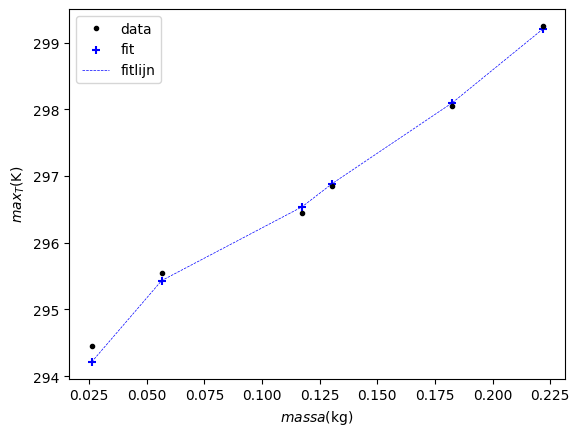

In [17]:

x = gewichten
y = max_temp
X = np.vstack((m_water, start_temp, gewichten))

opt, cov = curve_fit(tempfunc, X, y)

display(Markdown(f"De warmtecapaciteit van het onbekende materiaal is **{opt[0]:.1f}** J/(kg $\\cdot$ K)"))

# Maken van de grafiek
plt.figure()
plt.xlabel('$massa$(kg)')
plt.ylabel('$max_T$(K)')

plt.plot(x,y,'k.', label='data')
plt.scatter(x, tempfunc(X, *opt), c='blue', marker='+', label='fit')
plt.plot(x, tempfunc(X, *opt), c='blue', linestyle='--', linewidth=0.5, label='fitlijn')
#plt.savefig("figures/naam.png", dpi=450)
plt.legend()
plt.show()


```{figure} figures/naam.png
:width: 50%
:label: curve_fit

Op deze figuur hebben we de maximale bereikte temperatuur geplot in functie van de massa van de gebruikte gewichtjes. Er is geen lineair patroon en dat komt omdat er nog andere variabelen meespelen: De massa van het water en de startemperatuur van het water. Tijdens het experiment was het te moeilijk om deze telkens hetzelfde te zetten binnen een acceptabele marge. In plaats daarvan hebben we de maatbeker met ongeveer 200 gram water gevuld volgens de streepjes op de maatbeker en dan de precieze waarde gemeten op de weegschaal. Daarna hebben we ook de temperatuur van het water genoteerd voor de meting omdat deze ook licht varieerde. Deze variaties die niet op de x-as staan verstoren dus het lineaire patroon in de data. De fitlijn is er enkel om dit duidelijk te maken, er zijn geen waarden tussen de datapunten.
```

# Discussie en conclusie

De warmtecapaciteit van het onbekende materiaal is 388.3 J/(kg·K). Dit kunnen we gebruiken om het materiaal te identificeren. Dit zou megelijk een koperlegering kunnen zijn want de warmtecapaciteit van koper is ongeveer 385 J/(kg·K). 